In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_name = "/content/mtsamples.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [3]:
eda_folder = "/content/eda_diagrams"
os.makedirs(eda_folder, exist_ok=True)

print("EDA folder created:", eda_folder)

EDA folder created: /content/eda_diagrams


In [4]:
print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== FIRST 5 RECORDS ==========")
display(df.head())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all"))

========== DATASET SHAPE ==========
(4999, 6)

========== COLUMN NAMES ==========
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

========== DATA TYPES ==========
Unnamed: 0            int64
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

========== FIRST 5 RECORDS ==

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."



========== STATISTICAL SUMMARY ==========


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
count,4999.000000,4999,4999,4999,4966,3931
unique,NaN,2348,40,2377,2357,3849
top,NaN,An example/template for a routine normal male...,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTO...",
freq,NaN,12,1103,5,5,81
mean,2499.000000,NaN,NaN,NaN,NaN,NaN
std,1443.231328,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1249.500000,NaN,NaN,NaN,NaN,NaN
50%,2499.000000,NaN,NaN,NaN,NaN,NaN
75%,3748.500000,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


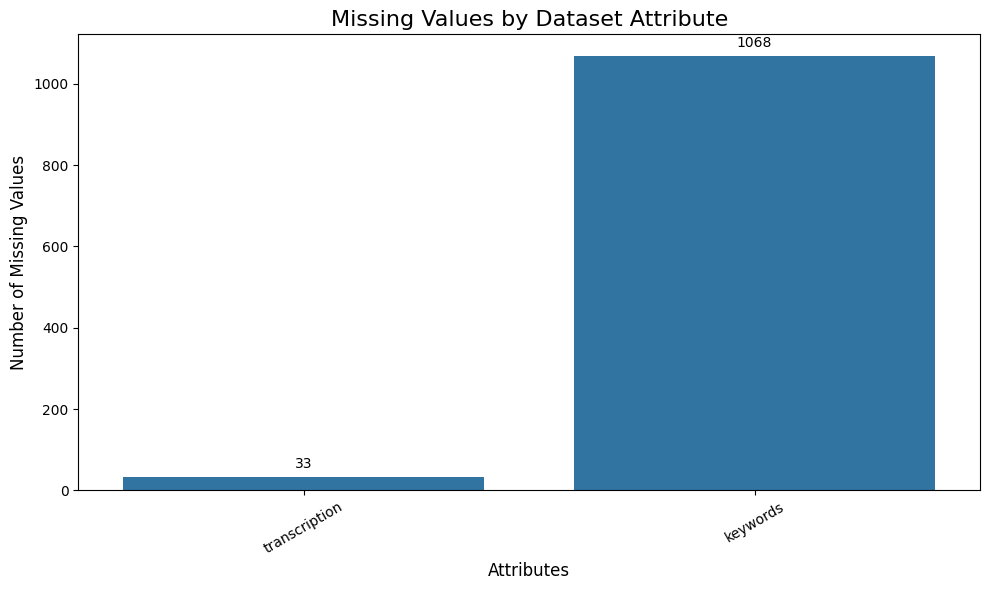

In [6]:
plt.figure(figsize=(10, 6))

missing_plot = missing_values[missing_values > 0]

if len(missing_plot) > 0:
    ax = sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values
    )

    plt.title("Missing Values by Dataset Attribute", fontsize=16)
    plt.xlabel("Attributes", fontsize=12)
    plt.ylabel("Number of Missing Values", fontsize=12)
    plt.xticks(rotation=30)

    for i, value in enumerate(missing_plot.values):
        ax.text(i, value + max(missing_plot.values) * 0.02,
                str(value), ha="center")

    plt.tight_layout()

    plt.savefig(
        f"{eda_folder}/01_missing_values.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("No missing values found.")

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [8]:
specialty_counts = df["medical_specialty"].value_counts()

print("Number of unique medical specialties:",
      df["medical_specialty"].nunique())

display(specialty_counts)

Number of unique medical specialties: 40


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


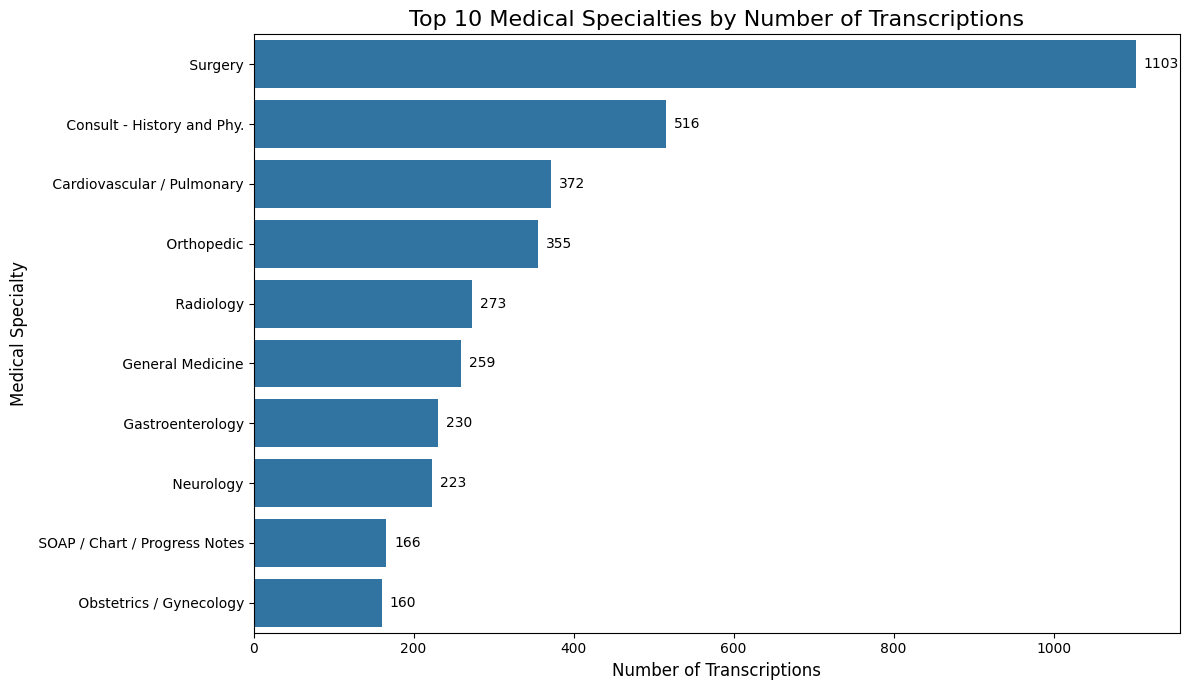

In [9]:
top10 = specialty_counts.head(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Medical Specialties by Number of Transcriptions",
          fontsize=16)
plt.xlabel("Number of Transcriptions", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

for i, value in enumerate(top10.values):
    ax.text(
        value + 10,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/02_top10_medical_specialties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

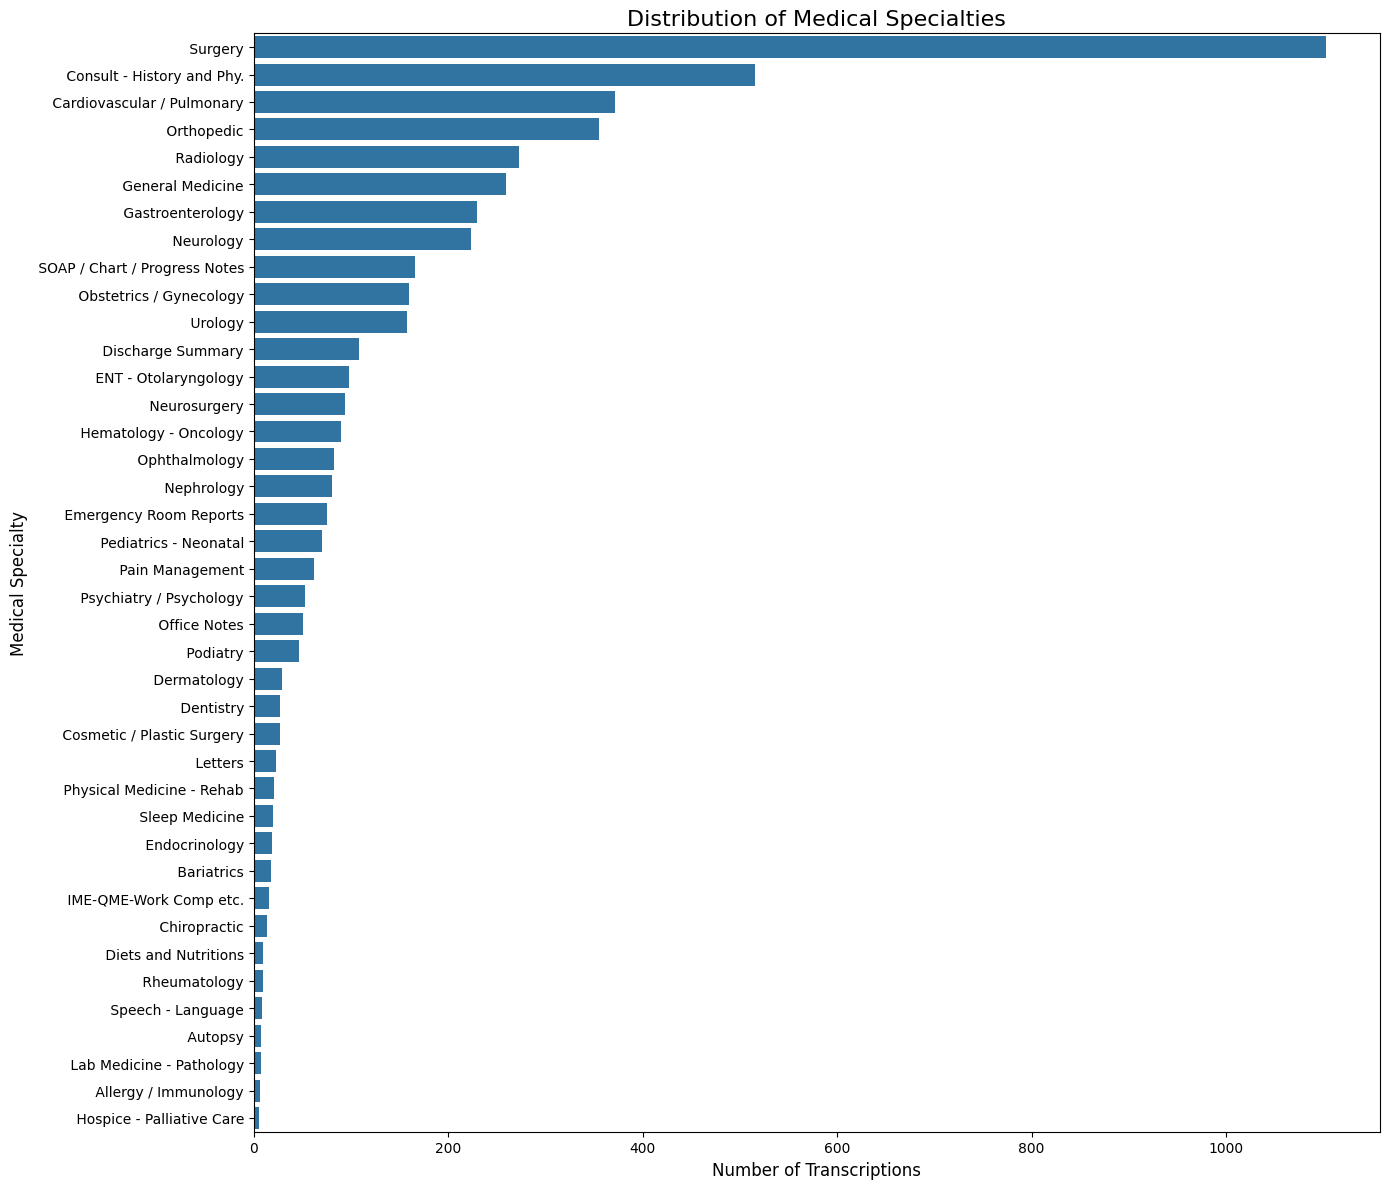

In [10]:
plt.figure(figsize=(14, 12))

ax = sns.barplot(
    x=specialty_counts.values,
    y=specialty_counts.index
)

plt.title("Distribution of Medical Specialties",
          fontsize=16)

plt.xlabel("Number of Transcriptions", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/03_complete_specialty_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
df["transcription_length"] = (
    df["transcription"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(df["transcription_length"].describe())

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: transcription_length, dtype: float64


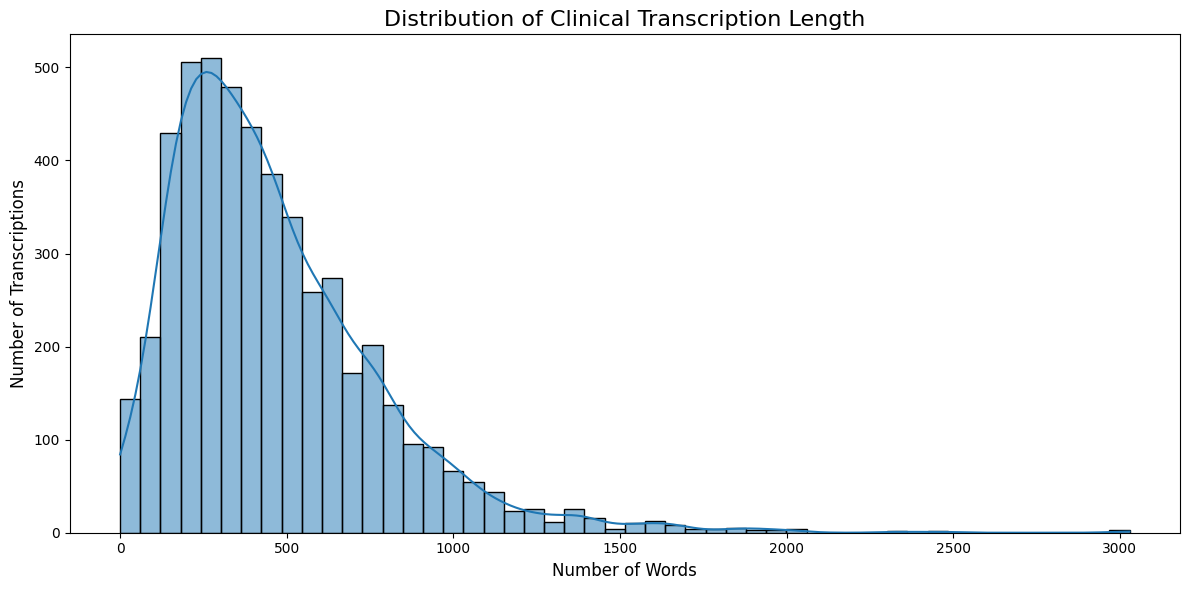

In [12]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["transcription_length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Clinical Transcription Length",
          fontsize=16)

plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Number of Transcriptions", fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/04_transcription_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

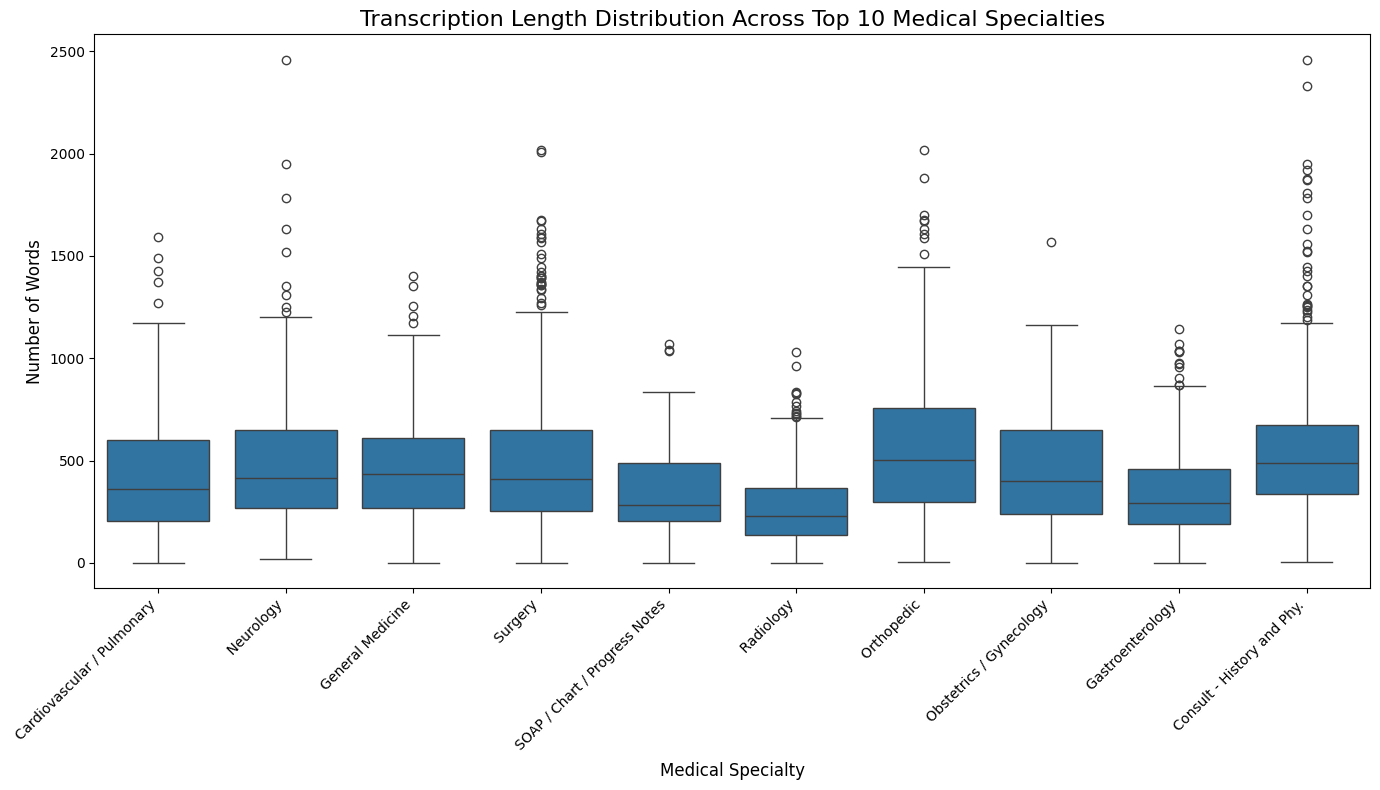

In [13]:
top_specialties = specialty_counts.head(10).index

plot_df = df[
    df["medical_specialty"].isin(top_specialties)
].copy()

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=plot_df,
    x="medical_specialty",
    y="transcription_length"
)

plt.title("Transcription Length Distribution Across Top 10 Medical Specialties",
          fontsize=16)

plt.xlabel("Medical Specialty", fontsize=12)
plt.ylabel("Number of Words", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/05_transcription_length_by_specialty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
!pip install wordcloud -q

In [15]:
from wordcloud import WordCloud, STOPWORDS

text_data = df["transcription"].dropna().astype(str)

all_text = " ".join(text_data)

print("Total characters used for word cloud:", len(all_text))

Total characters used for word cloud: 15162758


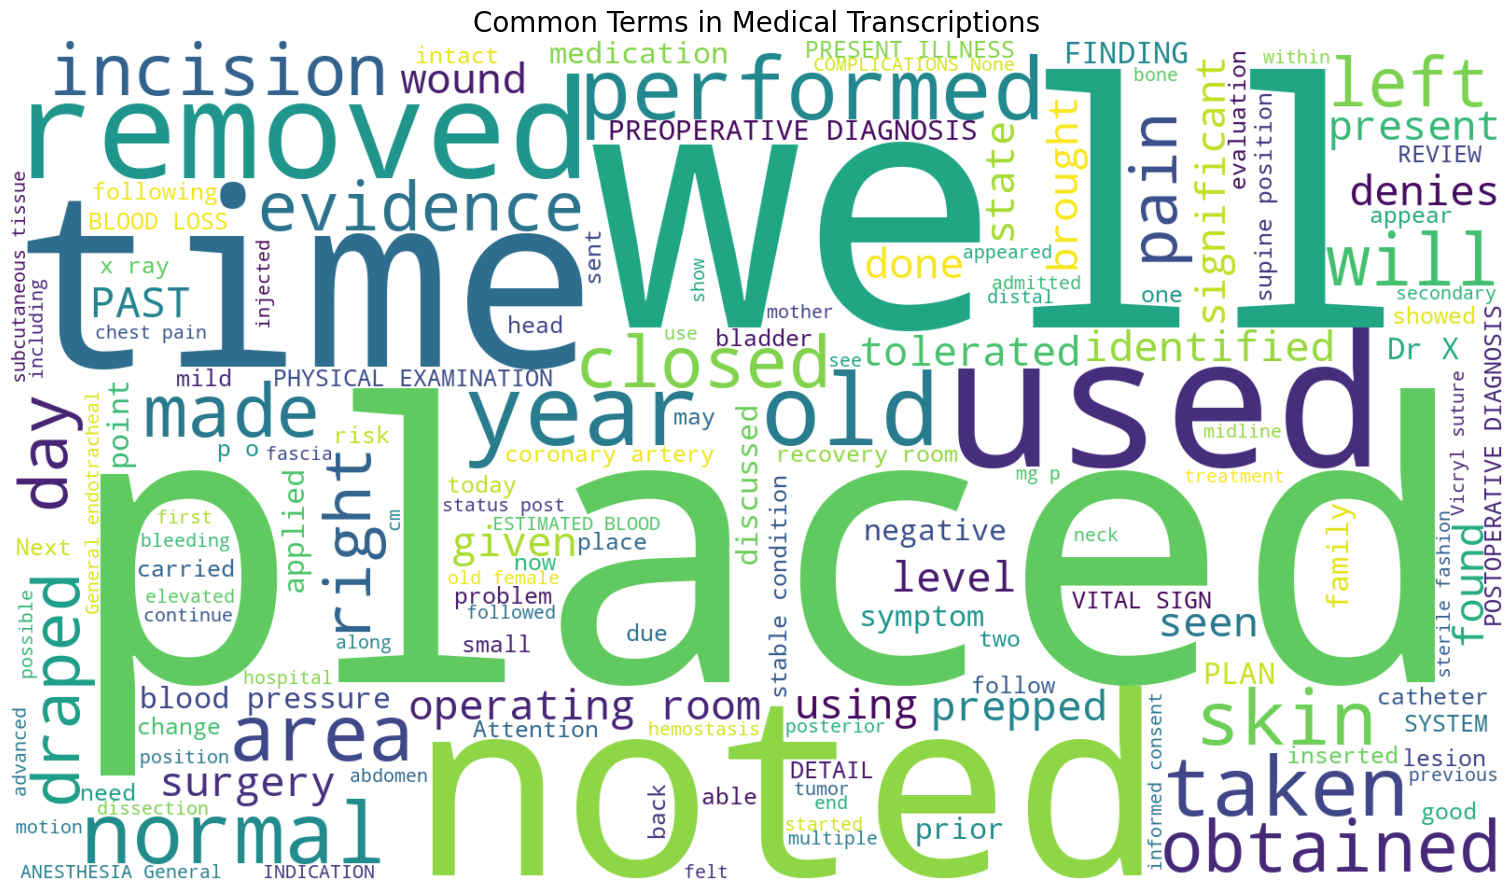

In [16]:
custom_stopwords = set(STOPWORDS)

# Add common non-informative words if needed
custom_stopwords.update([
    "patient",
    "patients",
    "history",
    "medical",
    "procedure",
    "report"
])

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=150
).generate(all_text)

plt.figure(figsize=(16, 9))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title(
    "Common Terms in Medical Transcriptions",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/06_medical_transcription_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
os.listdir(eda_folder)

['03_complete_specialty_distribution.png',
 '06_medical_transcription_wordcloud.png',
 '05_transcription_length_by_specialty.png',
 '04_transcription_length_distribution.png',
 '02_top10_medical_specialties.png',
 '01_missing_values.png']

In [18]:
import shutil

zip_path = shutil.make_archive(
    "/content/EDA_Diagrams",
    "zip",
    eda_folder
)

print("ZIP file created:", zip_path)

ZIP file created: /content/EDA_Diagrams.zip


In [19]:
from google.colab import files

files.download("/content/EDA_Diagrams.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

👆Up to Week 6 For Sprint release 1

# Week 7 - Data Preprocessing

In [20]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [22]:
df = pd.read_csv('/content/mtsamples.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [23]:
data = df[['transcription', 'medical_specialty']].copy()

print("Selected Dataset Shape:", data.shape)
data.head()

Selected Dataset Shape: (4999, 2)


,transcription,medical_specialty
0,"SUBJECTIVE:, This 23-year-old white female pr...",Allergy / Immunology
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",Bariatrics
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",Bariatrics
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary


In [24]:
print(data.isnull().sum())

transcription        33
medical_specialty     0
dtype: int64


Remove missing records

In [25]:
data = data.dropna(subset=['transcription', 'medical_specialty'])

print("Shape after removing missing values:", data.shape)

Shape after removing missing values: (4966, 2)


Check duplicates

In [26]:
print("Duplicate records:", data.duplicated().sum())

Duplicate records: 2


Then remove them:

In [27]:
data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (4964, 2)


Create text preprocessing function

In [28]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

Test preprocessing on one record

In [29]:
sample_text = data['transcription'].iloc[0]

print("Original Text:")
print(sample_text)

print("\nPreprocessed Text:")
print(preprocess_text(sample_text))

Original Text:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and swollen.  Only clear drainage was seen.  TMs were clear.,Neck:  Supple withou

Apply preprocessing

In [30]:
data['cleaned_transcription'] = data['transcription'].apply(preprocess_text)

data.head()

,transcription,medical_specialty,cleaned_transcription
0,"SUBJECTIVE:, This 23-year-old white female pr...",Allergy / Immunology,subjective year old white female present compl...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",Bariatrics,past medical history difficulty climbing stair...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",Bariatrics,history present illness seen abc today pleasan...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary,mode left atrial enlargement left atrial diame...
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary,left ventricular cavity size wall thickness ap...


Compare original and cleaned text

In [31]:
comparison = data[['transcription', 'cleaned_transcription']].head(3)

comparison

,transcription,cleaned_transcription
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective year old white female present compl...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history difficulty climbing stair...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history present illness seen abc today pleasan...


Checking the processed dataset

In [32]:
print("Dataset Shape:", data.shape)
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (4964, 3)

Missing Values:
transcription            0
medical_specialty        0
cleaned_transcription    0
dtype: int64


Check processed text length

In [33]:
data['cleaned_length'] = data['cleaned_transcription'].apply(lambda x: len(x.split()))

print(data['cleaned_length'].describe())

count    4964.000000
mean      275.788276
std       177.341015
min         1.000000
25%       146.000000
50%       244.000000
75%       361.000000
max      1674.000000
Name: cleaned_length, dtype: float64


Remove empty processed texts

In [34]:
data = data[data['cleaned_transcription'].str.strip() != '']

print("Final Preprocessed Shape:", data.shape)

Final Preprocessed Shape: (4964, 4)


Save the cleaned dataset

In [35]:
data.to_csv('/content/preprocessed_mtsamples.csv', index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.
